In [17]:
import pandas as pd
import numpy as np

# 1. Load the dataset safely with correct encoding
print("Loading data...")
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')# 2. Print initial shape
print(f"Dataset loaded! Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

# 3. View the first few rows
df.head()

Loading data...
Dataset loaded! Total rows: 541909, Total columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [18]:
# 1. Check basic data types and non-null counts
print("--- Dataset Information ---")
df.info()

# 2. See how many missing values are in each column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB

--- Missing Values Count ---
InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64


In [19]:
# 1. Ensure we only keep positive quantities and prices (removes returns & test entries)
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 2. Make sure CustomerID is treated strictly as a clean string ID
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

print("--- Cleaning Check ---")
print(f"Original rows: {df.shape[0]}")
print(f"Cleaned rows remaining: {df_clean.shape[0]}")
print(f"Rows removed (Returns/Errors): {df.shape[0] - df_clean.shape[0]}")

--- Cleaning Check ---
Original rows: 541909
Cleaned rows remaining: 530104
Rows removed (Returns/Errors): 11805


In [20]:
# 1. Create a Total Spending column for each individual transaction row
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 2. Make sure InvoiceDate is in datetime format so pandas can do date math
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 3. Establish our snapshot date (1 day after the very last transaction in the data)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date for Recency: {snapshot_date.strftime('%Y-%m-%d')}\n")

# 4. Group by CustomerID and calculate Recency, Frequency, and Monetary values
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Days since last purchase
    'InvoiceNo': 'nunique',                                 # Total unique orders placed
    'TotalSpend': 'sum'                                     # Total revenue generated
})

# 5. Rename columns for absolute clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

# 6. Display a summary of our brand new customer profile dataset
print(f"RFM Table Created! Total Unique Customers: {rfm.shape[0]}")
rfm.head()

Snapshot Date for Recency: 2011-12-10

RFM Table Created! Total Unique Customers: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [21]:
from sklearn.preprocessing import StandardScaler

# 1. Apply log transformation to flatten out huge exponential skewness
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])     # log1p handles any potential zeros safely
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# 2. Initialize a StandardScaler to give all columns an equal mean of 0 and variance of 1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. Convert back to a readable DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("--- Data Normalization Complete ---")
rfm_scaled_df.head()

--- Data Normalization Complete ---


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461535,-0.949128,3.688512
12347,-2.037091,1.063194,1.404171
12348,0.373300,0.380945,0.711859
12349,-0.622292,-0.949128,0.694187
12350,1.424122,-0.949128,-0.617748


In [22]:
from sklearn.preprocessing import StandardScaler

# 1. Apply log transformation to flatten out huge exponential skewness
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])     # log1p handles any potential zeros safely
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# 2. Initialize a StandardScaler to give all columns an equal mean of 0 and variance of 1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. Convert back to a readable DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("--- Data Normalization Complete ---")
rfm_scaled_df.head()


--- Data Normalization Complete ---


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461535,-0.949128,3.688512
12347,-2.037091,1.063194,1.404171
12348,0.373300,0.380945,0.711859
12349,-0.622292,-0.949128,0.694187
12350,1.424122,-0.949128,-0.617748


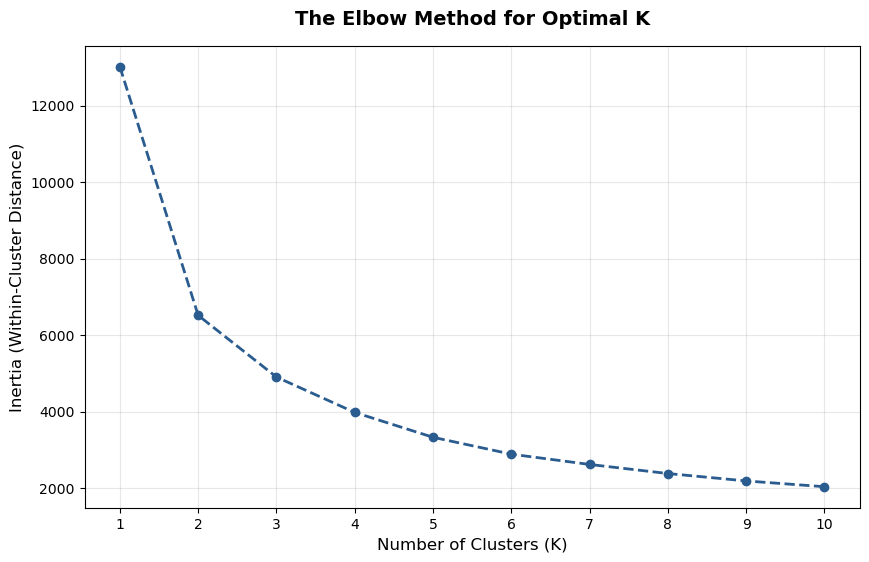

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Run K-Means for cluster numbers from 1 to 10 and record their inertia scores
inertia = []
K_range = range(1, 11)

for k in K_range:
    # Setting random_state ensures we get the exact same mathematical results every time
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# 2. Plot the results to see the "Elbow" curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='#2b5c8f', linewidth=2)
plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Distance)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# 1. Initialize K-Means with our optimal number of clusters (3)
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)

# 2. Fit the model on our scaled data matrix
kmeans_final.fit(rfm_scaled_df)

# 3. Assign the resulting cluster labels safely to our main RFM dataframe
rfm['Cluster'] = kmeans_final.labels_

# 4. View the final table with the new 'Cluster' column attached
print("--- Final Customer Segmentation Map ---")
rfm.head()

--- Final Customer Segmentation Map ---


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,0
12347,2,7,4310.00,1
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,2


In [25]:
# Calculate the mean (average) values for each cluster to interpret them
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'  # Tells us how many customers belong to each group
}).rename(columns={'Cluster': 'Customer_Count'})

print("--- Cluster Profiling Matrix ---")
cluster_analysis

--- Cluster Profiling Matrix ---


,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,44.254545,3.367742,1257.759333,1705
1,16.805699,15.152850,10166.910725,772
2,168.175175,1.354111,361.821494,1861


In [26]:
# 1. Define your updated human-readable mapping dictionary
cluster_map = {
    1: 'VIP Customers',
    0: 'Regular Shoppers',
    2: 'Churned / At-Risk'
}

# 2. Map the cluster numbers to your chosen names
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

# 3. Print out a quick snapshot to verify the names look great
print("--- Final Customer Personas Assigned ---")
rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head()

--- Final Customer Personas Assigned ---


,Recency,Frequency,Monetary,Segment
CustomerID,,,,
12346,326,1,77183.60,Regular Shoppers
12347,2,7,4310.00,VIP Customers
12348,75,4,1797.24,Regular Shoppers
12349,19,1,1757.55,Regular Shoppers
12350,310,1,334.40,Churned / At-Risk


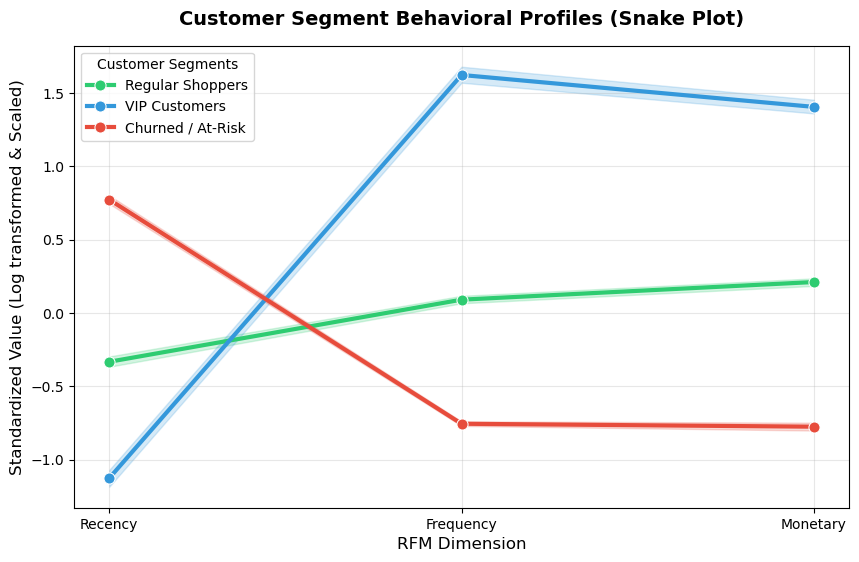

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Temporarily add the Segment labels to our scaled data for plotting
rfm_scaled_df['Segment'] = rfm['Segment']

# 2. Reshape the data so it's ready for a line plot
rfm_melted = pd.melt(rfm_scaled_df.reset_index(), 
                    id_vars=['CustomerID', 'Segment'],
                    value_vars=['Recency', 'Frequency', 'Monetary'],
                    var_name='Metric', 
                    value_name='Value')

# 3. Create the Snake Plot Canvas
plt.figure(figsize=(10, 6))
sns.lineplot(x='Metric', y='Value', hue='Segment', data=rfm_melted, 
             palette=['#2ecc71', '#3498db', '#e74c3c'], linewidth=3, marker='o', markersize=8)

plt.title('Customer Segment Behavioral Profiles (Snake Plot)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('RFM Dimension', fontsize=12)
plt.ylabel('Standardized Value (Log transformed & Scaled)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Customer Segments', frameon=True, facecolor='white')

# --- SAVE IT HERE (In the same cell before showing it) ---
plt.savefig('customer_segments_snake_plot.png', dpi=300, bbox_inches='tight')

# 4. Display the plot down below
plt.show()

In [28]:
# Save the final unscaled RFM dataframe with its descriptive labels to a clean CSV file
rfm.to_csv('segmented_customer_data.csv', index=True)

print("--- Data Export Successful! ---")
print("File saved as: 'segmented_customer_data.csv' in your workspace.")

--- Data Export Successful! ---
File saved as: 'segmented_customer_data.csv' in your workspace.


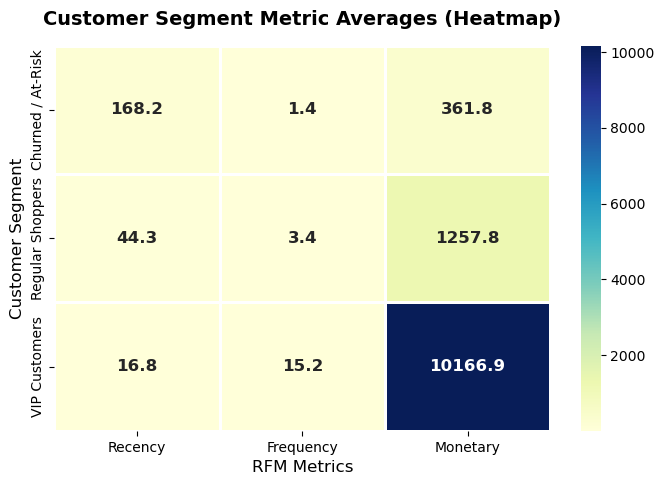

In [29]:
import numpy as np

# 1. Calculate the exact average RFM metrics for our named segments
segment_averages = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

# 2. Plot the Heatmap
plt.figure(figsize=(8, 5))
# annot=True puts the actual numbers inside the squares
# fmt='.1f' rounds the values to 1 decimal place for absolute cleanliness
sns.heatmap(segment_averages, annot=True, fmt='.1f', cmap='YlGnBu', cbar=True,
            linewidths=1, linecolor='white', annot_kws={"size": 12, "weight": "bold"})

plt.title('Customer Segment Metric Averages (Heatmap)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Customer Segment', fontsize=12)
plt.xlabel('RFM Metrics', fontsize=12)

# 3. Save the crisp layout permanently to your sidebar workspace
plt.savefig('customer_segments_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [30]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score for our 3-cluster model
# We pass it the scaled data and the final cluster labels the model predicted
sil_score = silhouette_score(rfm_scaled_df.drop(columns=['Segment'], errors='ignore'), rfm['Cluster'])

print("--- Model Validation Metrics ---")
print(f"Final Silhouette Score: {sil_score:.4f}")

--- Model Validation Metrics ---
Final Silhouette Score: 0.3358


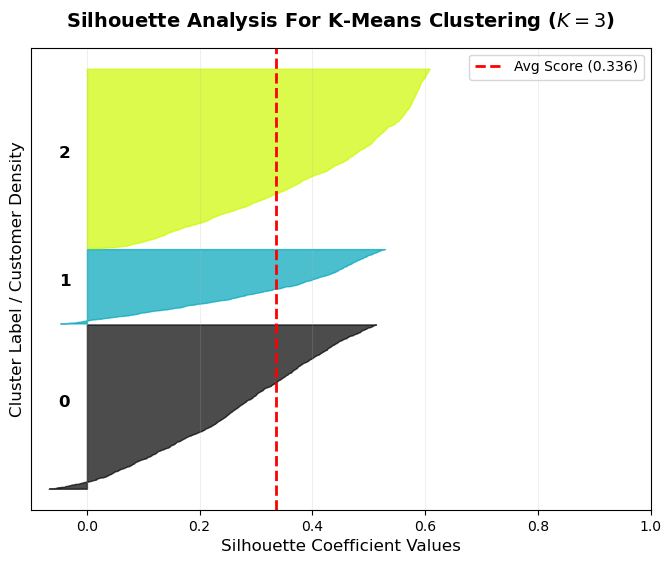

In [31]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

# 1. Prepare data and isolate the cluster labels
X_matrix = rfm_scaled_df.drop(columns=['Segment'], errors='ignore')
cluster_labels = rfm['Cluster']
n_clusters = 3

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# 2. Calculate the silhouette values for each specific customer sample
sample_silhouette_values = silhouette_samples(X_matrix, cluster_labels)

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), 
             fontweight='bold', fontsize=12)

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette Analysis For K-Means Clustering ($K = 3$)", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Silhouette Coefficient Values", fontsize=12)
ax1.set_ylabel("Cluster Label / Customer Density", fontsize=12)

# The vertical line for average silhouette score of all the values
ax1.axvline(x=sil_score, color="red", linestyle="--", linewidth=2, label=f'Avg Score ({sil_score:.3f})')
ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xlim([-0.1, 1])
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.2)

# Save the validation chart
plt.savefig('customer_segments_silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
import pickle

# Force saving using Protocol 4 so Python 3.7 can read it smoothly
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f, protocol=4)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f, protocol=4)

print("--- Module 1 Artifacts Saved with Protocol 4 Successfully! ---")

--- Module 1 Artifacts Saved with Protocol 4 Successfully! ---
